In [33]:
print('Data source import complete.')

import os
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    roc_auc_score,
    average_precision_score,
    top_k_accuracy_score
)
from sklearn.preprocessing import label_binarize

print("TensorFlow version:", tf.__version__)

Data source import complete.
TensorFlow version: 2.19.0


In [34]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_ROOT = Path("/kaggle/input/datasets/nat5natalia/butterfly-dataset/data/raw")
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 12
FINE_TUNE_EPOCHS = 12
TARGET_PER_CLASS = 150

In [35]:
# --- Reproducibility hardening (best effort) ---
import tensorflow as tf
from pathlib import Path
import hashlib

tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()

# 1) Sort directories and file listing to stabilize df row order
class_dirs = sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()], key=lambda p: p.name)

rows = []
for class_dir in class_dirs:
    label = class_dir.name
    images = sorted(
        [p for p in class_dir.rglob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".webp")],
        key=lambda p: p.name
    )
    for img_path in images:
        rows.append({"filepath": str(img_path), "label": label})

df = pd.DataFrame(rows)

# 2) After you create train_df/val_df/test_df, SAVE them for a fixed split
SPLITS_DIR = OUTPUT_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)

with open(SPLITS_DIR / "split_sha256.txt", "w") as f:
    f.write(f"train.csv {sha256_file(SPLITS_DIR / 'train.csv')}\n")
    f.write(f"val.csv   {sha256_file(SPLITS_DIR / 'val.csv')}\n")
    f.write(f"test.csv  {sha256_file(SPLITS_DIR / 'test.csv')}\n")


In [36]:
from pathlib import Path
import pandas as pd

def fix_paths(df, dataset_root):
    fixed_paths = []

    for p in df["filepath"]:
        p = Path(p)

        # Case 1: already correct
        if p.exists():
            fixed_paths.append(str(p))
            continue

        # Case 2: take only filename
        filename = p.name

        matches = list(dataset_root.rglob(filename))

        if len(matches) == 0:
            raise FileNotFoundError(f"File not found: {filename}")

        if len(matches) > 1:
            print(f"Warning: multiple matches for {filename}, taking first")

        fixed_paths.append(str(matches[0]))

    df = df.copy()
    df["filepath"] = fixed_paths
    return df

In [37]:
class_dirs = [p for p in DATASET_ROOT.iterdir() if p.is_dir()]

rows = []

for class_dir in class_dirs:
    label = class_dir.name
    for img_path in class_dir.rglob("*"):
        if img_path.suffix.lower() in (".jpg", ".jpeg", ".png", ".webp"):
            rows.append({
                "filepath": str(img_path),
                "label": label
            })

df = pd.DataFrame(rows)

print("Total images:", len(df))
print("Classes:", len(class_dirs))

Total images: 1590
Classes: 8


In [38]:
TARGET_PER_CLASS = 150

df = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(n=TARGET_PER_CLASS, random_state=SEED))
      .reset_index(drop=True)
)


/tmp/ipykernel_55/2770760274.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=TARGET_PER_CLASS, random_state=SEED))


In [39]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

class_names = sorted(train_df["label"].unique())
class_map = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_map.items()}

with open(OUTPUT_DIR / "class_indices.json", "w") as f:
    json.dump(class_map, f, indent=2)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Num classes:", len(class_names))

Train: 840 Val: 180 Test: 180
Num classes: 8


In [40]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

In [41]:
def decode_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)  # без /255
    return img, tf.cast(label, tf.int32)

def make_dataset(df, shuffle=False):
    paths = df["filepath"].values
    labels = df["label"].map(class_map).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(2048, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

In [42]:
train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

In [43]:
NUM_CLASSES = len(class_map)

def get_preprocess_layer(model_name):
    if model_name == "mobilenet":
        return tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input, name="preprocess")
    elif model_name == "efficientnet":
        # EfficientNetB0 в Keras уже содержит корректную внутреннюю preprocessing-логику,
        # поэтому оставляем вход как есть.
        return tf.keras.layers.Lambda(lambda x: x, name="preprocess")
    else:
        raise ValueError("Unknown model_name")

def get_base_model(model_name, input_shape=(224, 224, 3)):
    if model_name == "mobilenet":
        base = tf.keras.applications.MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
    elif model_name == "efficientnet":
        base = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
    else:
        raise ValueError("Unknown model_name")
    return base

def build_transfer_model(model_name, num_classes, trainable=False, dropout_rate=0.2):
    inputs = tf.keras.Input(shape=(224, 224, 3), name="input_image")
    x = data_augmentation(inputs)
    x = get_preprocess_layer(model_name)(x)

    base_model = get_base_model(model_name, input_shape=(224, 224, 3))
    base_model.trainable = trainable

    x = base_model(x, training=False if not trainable else True)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=f"{model_name}_{'ft' if trainable else 'frozen'}")
    return model, base_model

In [44]:
def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_accuracy")
        ]
    )

def get_callbacks(model_name):
    ckpt_path = OUTPUT_DIR / f"{model_name}_best.keras"
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(ckpt_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]
    return callbacks

In [45]:
def train_frozen_model(model_label, backbone_name):
    model, base_model = build_transfer_model(
        model_name=backbone_name,
        num_classes=NUM_CLASSES,
        trainable=False
    )
    compile_model(model, learning_rate=1e-3)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=get_callbacks(model_label),
        verbose=1
    )
    return model, base_model, history

In [46]:
def train_finetuned_mobilenet():
    model, base_model = build_transfer_model(
        model_name="mobilenet",
        num_classes=NUM_CLASSES,
        trainable=False
    )
    compile_model(model, learning_rate=1e-3)

    print("Stage 1: train classifier head")
    history_stage1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=get_callbacks("mobilenetv2_frozen_stage"),
        verbose=1
    )

    print("Stage 2: fine-tuning top layers")
    base_model.trainable = True

    fine_tune_at = len(base_model.layers) - 30
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    compile_model(model, learning_rate=1e-5)

    history_stage2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=get_callbacks("mobilenetv2_finetuned"),
        verbose=1
    )

    return model, base_model, history_stage1, history_stage2

In [47]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist["accuracy"], label="train_acc")
    plt.plot(hist["val_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

def combine_histories(hist1, hist2):
    combined = {}
    for key in hist1.history.keys():
        combined[key] = hist1.history[key] + hist2.history[key]
    class DummyHistory:
        pass
    h = DummyHistory()
    h.history = combined
    return h

In [48]:
def get_predictions(model, dataset):
    y_true = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_prob.extend(probs)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = np.argmax(y_prob, axis=1)

    return y_true, y_pred, y_prob

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, model_name, dataset, class_names):
    y_true, y_pred, y_prob = get_predictions(model, dataset)

    acc = accuracy_score(y_true, y_pred)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))

    roc_auc_macro = roc_auc_score(
        y_true_bin, y_prob, multi_class="ovr", average="macro"
    )
    roc_auc_weighted = roc_auc_score(
        y_true_bin, y_prob, multi_class="ovr", average="weighted"
    )

    pr_auc_macro = average_precision_score(
        y_true_bin, y_prob, average="macro"
    )

    top3_acc = top_k_accuracy_score(
        y_true, y_prob, k=3, labels=np.arange(len(class_names))
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print(report_text)

    plot_confusion_matrix(cm, class_names, title=f"{model_name} - Confusion Matrix")

    metrics = {
        "Model": model_name,
        "Accuracy": acc,
        "Precision_macro": p_macro,
        "Recall_macro": r_macro,
        "F1_macro": f1_macro,
        "Precision_weighted": p_weighted,
        "Recall_weighted": r_weighted,
        "F1_weighted": f1_weighted,
        "ROC_AUC_macro_OvR": roc_auc_macro,
        "ROC_AUC_weighted_OvR": roc_auc_weighted,
        "PR_AUC_macro": pr_auc_macro,
        "Top3_Accuracy": top3_acc
    }

    with open(OUTPUT_DIR / f"{model_name}_classification_report.json", "w") as f:
        json.dump(report_dict, f, indent=2)

    pd.DataFrame(report_dict).transpose().to_csv(
        OUTPUT_DIR / f"{model_name}_classification_report.csv"
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_confusion_matrix.png")
    plt.show()

    return metrics, y_true, y_pred, y_prob, report_dict, cm

Training model 1/3: MobileNetV2 Frozen
Epoch 1/12
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3305 - loss: 2.1227 - top3_accuracy: 0.6111
Epoch 1: val_loss improved from inf to 1.17570, saving model to /kaggle/working/outputs/MobileNetV2_Frozen_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.3370 - loss: 2.0983 - top3_accuracy: 0.6184 - val_accuracy: 0.6500 - val_loss: 1.1757 - val_top3_accuracy: 0.8667 - learning_rate: 0.0010
Epoch 2/12
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6672 - loss: 1.0912 - top3_accuracy: 0.8748
Epoch 2: val_loss improved from 1.17570 to 0.89214, saving model to /kaggle/working/outputs/MobileNetV2_Frozen_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.6691 - loss: 1.0809 - top3_accuracy: 0.8758 - val_accuracy: 0.7167 - val_loss: 0.8921 - val_top3_accuracy: 0.9056 - learning_rate: 0.0010
Epoch 3/12
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7548 - loss: 0.7397 - top3_accuracy: 0.9308
Epoch 3

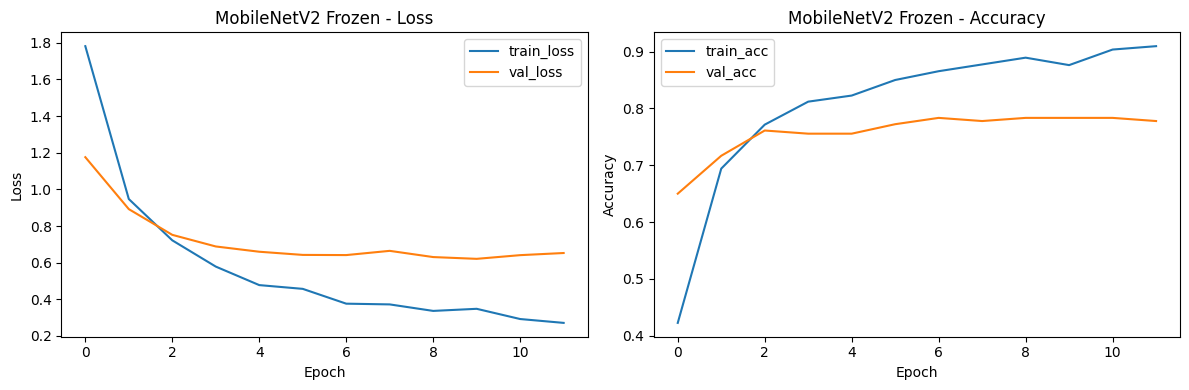

2026-03-31 22:48:47.159238: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



===== MobileNetV2_Frozen =====
                     precision    recall  f1-score   support

            admiral       0.89      0.73      0.80        22
      cabbage_white       0.91      0.91      0.91        22
        common_blue       0.85      0.96      0.90        23
            monarch       0.76      0.70      0.73        23
       painted_lady       0.82      0.78      0.80        23
            peacock       0.90      0.82      0.86        22
silvery_checkerspot       0.56      0.78      0.65        23
  tiger_swallowtail       0.84      0.73      0.78        22

           accuracy                           0.80       180
          macro avg       0.82      0.80      0.80       180
       weighted avg       0.81      0.80      0.80       180



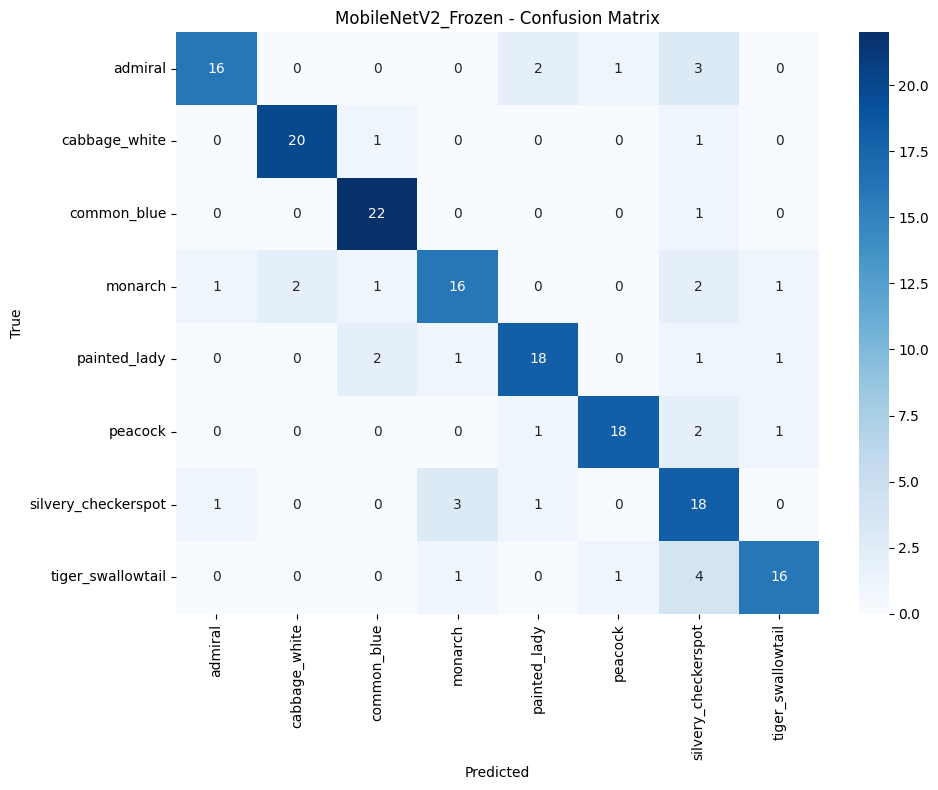

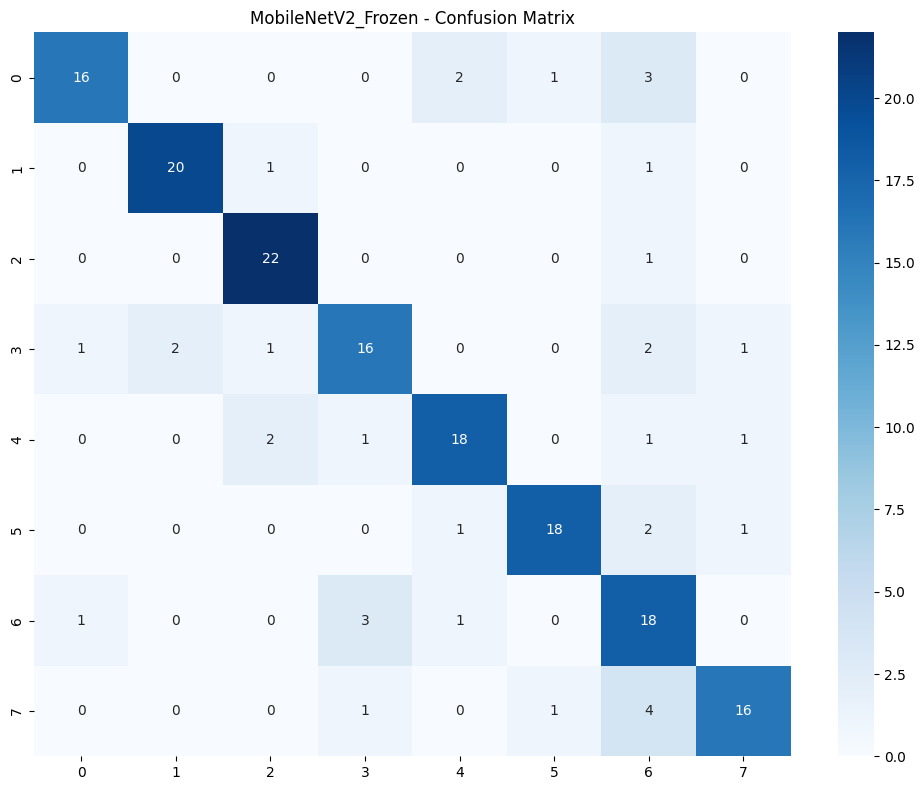

In [49]:
all_results = {}
trained_models = {}
all_histories = {}
all_predictions = {}
all_reports = {}
all_confusion_matrices = {}

# 1) MobileNetV2 baseline (pretrained, frozen backbone)
print("Training model 1/3: MobileNetV2 Frozen")

mobilenet_frozen_model, mobilenet_frozen_base, mobilenet_frozen_history = train_frozen_model(
    model_label="MobileNetV2_Frozen",
    backbone_name="mobilenet"
)

plot_history(mobilenet_frozen_history, "MobileNetV2 Frozen")

metrics, y_true, y_pred, y_prob, report_dict, cm = evaluate_model(
    mobilenet_frozen_model,
    "MobileNetV2_Frozen",
    test_ds,
    class_names
)

all_results["MobileNetV2_Frozen"] = metrics
trained_models["MobileNetV2_Frozen"] = mobilenet_frozen_model
all_histories["MobileNetV2_Frozen"] = mobilenet_frozen_history
all_predictions["MobileNetV2_Frozen"] = (y_true, y_pred, y_prob)
all_reports["MobileNetV2_Frozen"] = report_dict
all_confusion_matrices["MobileNetV2_Frozen"] = cm

Training model 2/3: MobileNetV2 Fine-Tuned
Stage 1: train classifier head
Epoch 1/12
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.2455 - loss: 2.3799 - top3_accuracy: 0.5463
Epoch 1: val_loss improved from inf to 1.21264, saving model to /kaggle/working/outputs/mobilenetv2_frozen_stage_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.2546 - loss: 2.3462 - top3_accuracy: 0.5555 - val_accuracy: 0.6556 - val_loss: 1.2126 - val_top3_accuracy: 0.8444 - learning_rate: 0.0010
Epoch 2/12
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6674 - loss: 1.0353 - top3_accuracy: 0.8690
Epoch 2: val_loss improved from 1.21264 to 0.92180, saving model to /kaggle/working/outputs/mobilenetv2_frozen_stage_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.6696 - loss: 1.0299 - top3_accuracy: 0.8699 - val_accuracy: 0.7167 - val_loss: 0.9218 - val_top3_accuracy: 0.8944 - learning_rate: 0.0010
Epoch 3/12
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7557

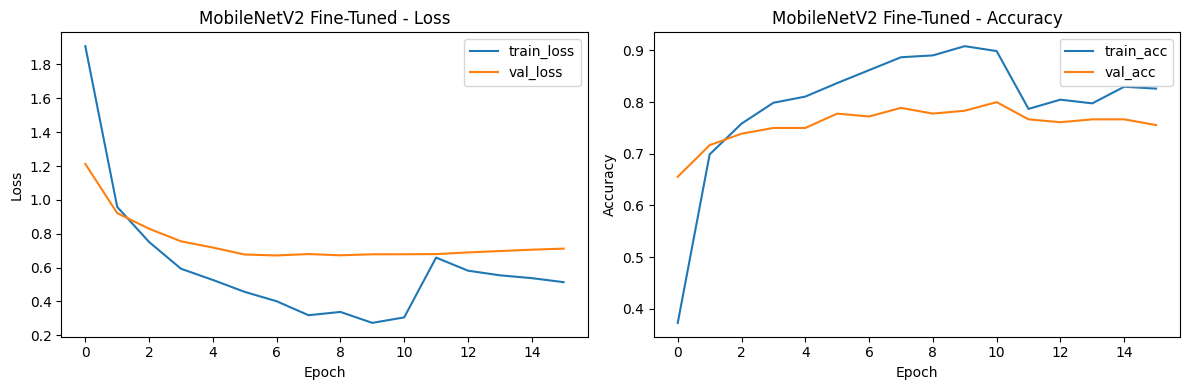

2026-03-31 22:50:22.838558: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



===== MobileNetV2_FineTuned =====
                     precision    recall  f1-score   support

            admiral       0.95      0.82      0.88        22
      cabbage_white       0.81      1.00      0.90        22
        common_blue       0.96      0.96      0.96        23
            monarch       0.84      0.70      0.76        23
       painted_lady       0.80      0.87      0.83        23
            peacock       0.82      0.82      0.82        22
silvery_checkerspot       0.75      0.78      0.77        23
  tiger_swallowtail       0.76      0.73      0.74        22

           accuracy                           0.83       180
          macro avg       0.84      0.83      0.83       180
       weighted avg       0.84      0.83      0.83       180



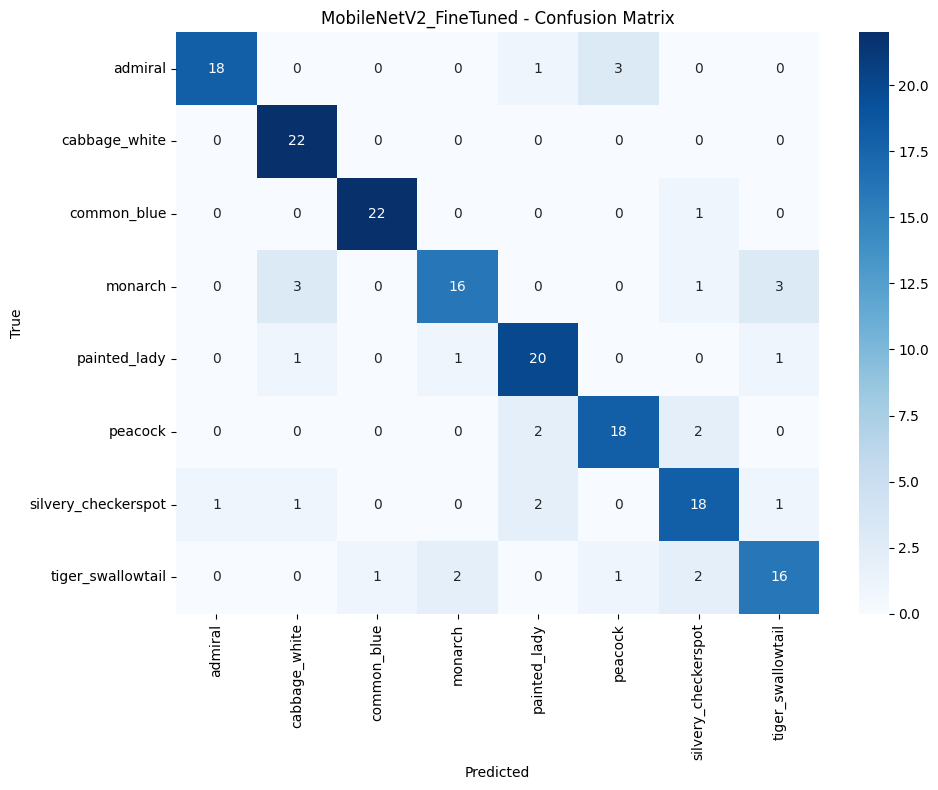

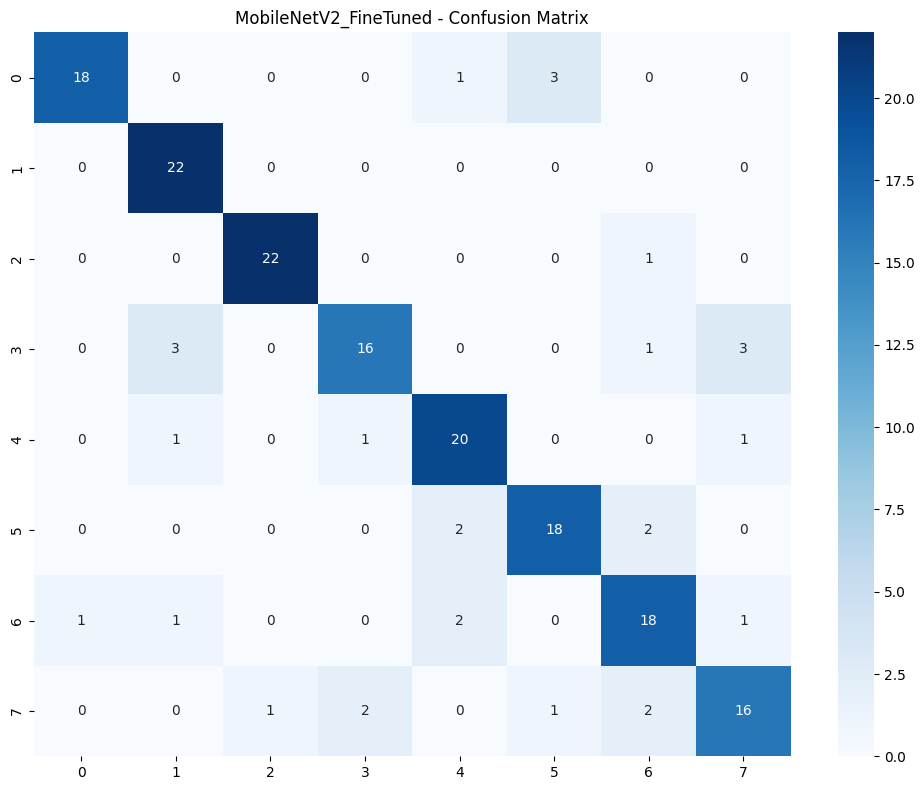

In [50]:
# 2) MobileNetV2 fine-tuned
print("Training model 2/3: MobileNetV2 Fine-Tuned")

mobilenet_ft_model, mobilenet_ft_base, hist_stage1, hist_stage2 = train_finetuned_mobilenet()
mobilenet_ft_history = combine_histories(hist_stage1, hist_stage2)

plot_history(mobilenet_ft_history, "MobileNetV2 Fine-Tuned")

metrics, y_true, y_pred, y_prob, report_dict, cm = evaluate_model(
    mobilenet_ft_model,
    "MobileNetV2_FineTuned",
    test_ds,
    class_names
)

all_results["MobileNetV2_FineTuned"] = metrics
trained_models["MobileNetV2_FineTuned"] = mobilenet_ft_model
all_histories["MobileNetV2_FineTuned"] = mobilenet_ft_history
all_predictions["MobileNetV2_FineTuned"] = (y_true, y_pred, y_prob)
all_reports["MobileNetV2_FineTuned"] = report_dict
all_confusion_matrices["MobileNetV2_FineTuned"] = cm

Training model 3/3: EfficientNetB0 Frozen
Epoch 1/12


E0000 00:00:1774997436.782609      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnet_frozen_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3000 - loss: 2.2256 - top3_accuracy: 0.5754
Epoch 1: val_loss improved from inf to 1.32066, saving model to /kaggle/working/outputs/EfficientNetB0_Frozen_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 229ms/step - accuracy: 0.3082 - loss: 2.1983 - top3_accuracy: 0.5826 - val_accuracy: 0.7056 - val_loss: 1.3207 - val_top3_accuracy: 0.9056 - learning_rate: 0.0010
Epoch 2/12
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7259 - loss: 0.8346 - top3_accuracy: 0.9196
Epoch 2: val_loss improved from 1.32066 to 0.98813, saving model to /kaggle/working/outputs/EfficientNetB0_Frozen_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.7255 - loss: 0.8353 - top3_accuracy: 0.9189 - val_accuracy: 0.8111 - val_loss: 0.9881 - val_top3_accuracy: 0.9389 - learning_rate: 0.0010
Epoch 3/12
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7964 - loss: 0.6252 - top3_accuracy: 0.9456
Epoch 3: val_loss improved from 0.98813 to 0.81505,

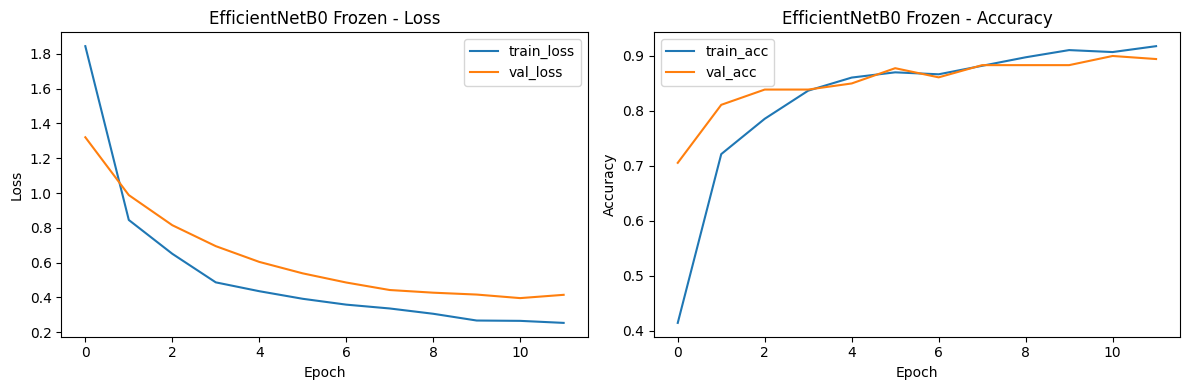

2026-03-31 22:51:47.583895: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



===== EfficientNetB0_Frozen =====
                     precision    recall  f1-score   support

            admiral       0.86      0.82      0.84        22
      cabbage_white       0.91      0.95      0.93        22
        common_blue       0.96      1.00      0.98        23
            monarch       0.65      0.74      0.69        23
       painted_lady       0.90      0.83      0.86        23
            peacock       0.83      0.86      0.84        22
silvery_checkerspot       0.91      0.87      0.89        23
  tiger_swallowtail       0.85      0.77      0.81        22

           accuracy                           0.86       180
          macro avg       0.86      0.86      0.86       180
       weighted avg       0.86      0.86      0.86       180



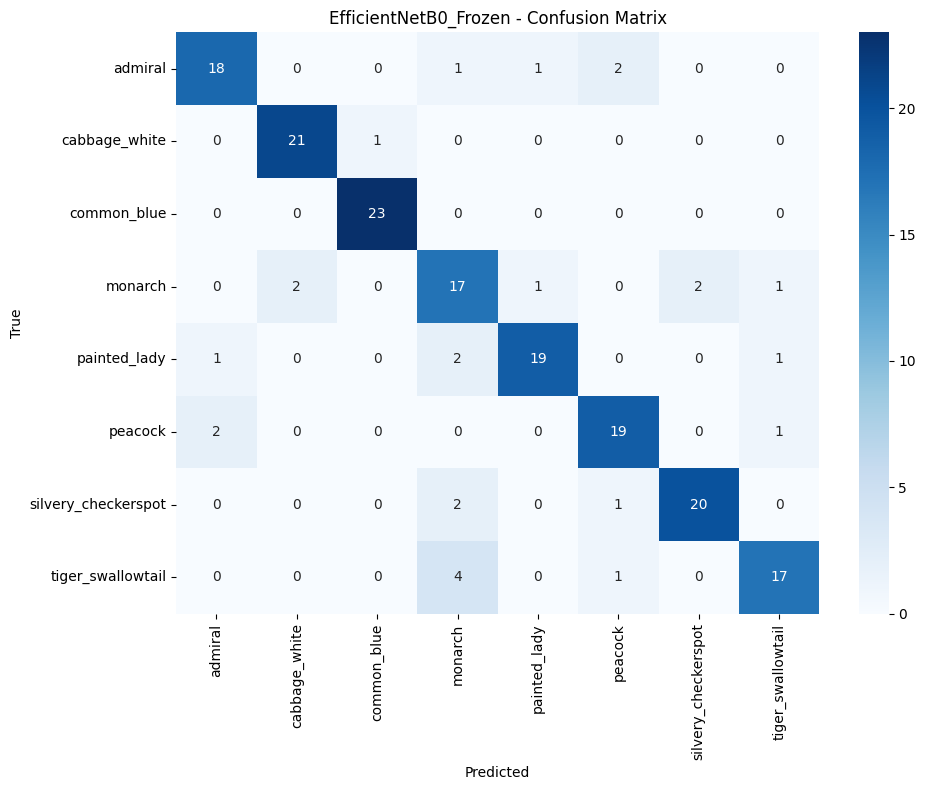

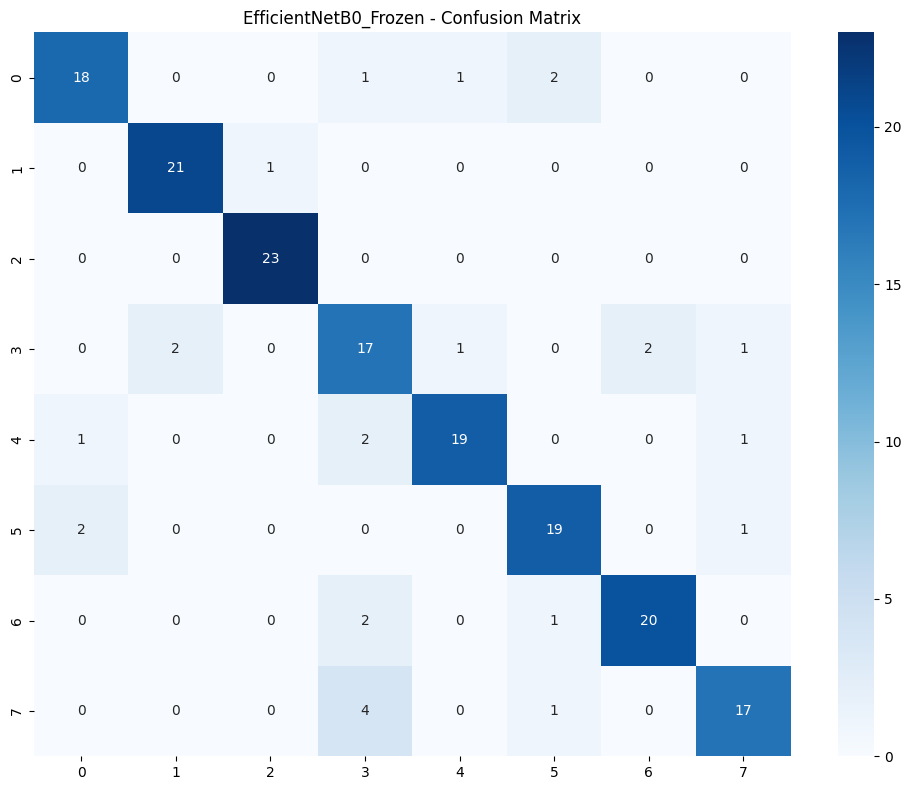


All 3 models have been trained and evaluated.
Available models: ['MobileNetV2_Frozen', 'MobileNetV2_FineTuned', 'EfficientNetB0_Frozen']


In [51]:
# 3) EfficientNetB0 baseline (pretrained, frozen backbone)
print("Training model 3/3: EfficientNetB0 Frozen")

efficientnet_model, efficientnet_base, efficientnet_history = train_frozen_model(
    model_label="EfficientNetB0_Frozen",
    backbone_name="efficientnet"
)

plot_history(efficientnet_history, "EfficientNetB0 Frozen")

metrics, y_true, y_pred, y_prob, report_dict, cm = evaluate_model(
    efficientnet_model,
    "EfficientNetB0_Frozen",
    test_ds,
    class_names
)
all_results["EfficientNetB0_Frozen"] = metrics
trained_models["EfficientNetB0_Frozen"] = efficientnet_model
all_histories["EfficientNetB0_Frozen"] = efficientnet_history
all_predictions["EfficientNetB0_Frozen"] = (y_true, y_pred, y_prob)
all_reports["EfficientNetB0_Frozen"] = report_dict
all_confusion_matrices["EfficientNetB0_Frozen"] = cm

print("\nAll 3 models have been trained and evaluated.")
print("Available models:", list(all_results.keys()))

In [52]:
comparison_df = pd.DataFrame(all_results.values())
comparison_df = comparison_df[[
    "Model", "Accuracy", "F1_macro", "ROC_AUC_macro_OvR", "Top3_Accuracy",
    "Precision_macro", "Recall_macro", "F1_weighted", "PR_AUC_macro"
]].sort_values(by="F1_macro", ascending=False)

comparison_df.to_csv(OUTPUT_DIR / "final_model_comparison.csv", index=False)
comparison_df

,Model,Accuracy,F1_macro,ROC_AUC_macro_OvR,Top3_Accuracy,Precision_macro,Recall_macro,F1_weighted,PR_AUC_macro
2,EfficientNetB0_Frozen,0.855556,0.856205,0.986143,0.966667,0.859038,0.855484,0.856206,0.943297
1,MobileNetV2_FineTuned,0.833333,0.832012,0.978589,0.972222,0.836362,0.833498,0.831954,0.911244
0,MobileNetV2_Frozen,0.800000,0.803312,0.972683,0.938889,0.816103,0.799901,0.802571,0.890587


In [53]:
best_row = comparison_df.iloc[0]
best_model_name = best_row["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print(best_row)

Best model: EfficientNetB0_Frozen
Model                EfficientNetB0_Frozen
Accuracy                          0.855556
F1_macro                          0.856205
ROC_AUC_macro_OvR                 0.986143
Top3_Accuracy                     0.966667
Precision_macro                   0.859038
Recall_macro                      0.855484
F1_weighted                       0.856206
PR_AUC_macro                      0.943297
Name: 2, dtype: object


In [54]:
y_true, y_pred, y_prob = all_predictions[best_model_name]

with open(OUTPUT_DIR / "best_metrics.json", "w") as f:
    json.dump(all_reports[best_model_name], f, indent=2)

pd.DataFrame(all_reports[best_model_name]).transpose().to_csv(
    OUTPUT_DIR / "results_summary.csv"
)

In [55]:
MIS_DIR = OUTPUT_DIR / "misclassified_examples"
MIS_DIR.mkdir(exist_ok=True)

df_test = test_df.reset_index(drop=True)

mis_count = 0
for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        img = plt.imread(df_test.loc[i, "filepath"])
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"T: {class_names[y_true[i]]}\nP: {class_names[y_pred[i]]}")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(MIS_DIR / f"{i}.png")
        plt.close()
        mis_count += 1

print("Saved misclassified examples:", mis_count)

Saved misclassified examples: 26


peacock 0.5882105231285095


2026-03-31 22:51:55.685614: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


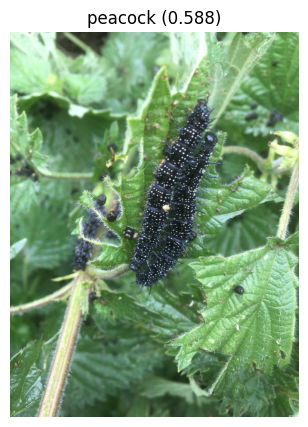

In [56]:
from PIL import Image

def prepare_single_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    x = np.array(img).astype("float32")
    x = np.expand_dims(x, axis=0)
    return x

def predict_image(path, model=None):
    if model is None:
        model = best_model

    x = prepare_single_image(path)
    preds = model.predict(x, verbose=0)
    idx = np.argmax(preds)
    return class_names[idx], float(np.max(preds))

sample = test_df.iloc[0]["filepath"]
label, conf = predict_image(sample, model=best_model)

print(label, conf)

img = plt.imread(sample)
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"{label} ({conf:.3f})")
plt.axis("off")
plt.show()